## **Lake model calibration example notebook**
____

**What you need to use this code:**
* Modeled profiles of water temperature 
* A .csv file of observations, where columns are depth (in meters) and variable (temperature in deg C or water d2H in per mil)
* The parameter-values-tested.csv file, that's written in the 'model' directory. This holds the parameter values used for each parameter in each model run. 

**What this code does:**
* Compares observations with modeled values by linearly interpolating modeled values to observation depths 
* Visualizes distribution of best parameters in a scatterplot 
* Creates a heatmap with modeled values and observations plotted on top 
* Creates a timeseries at selected depths with modeled values and observations plotted on top

___
Author: Rebecca G. Topness <br>
Last updated: 20260428

In [1]:
# Import packages
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import math
import matplotlib.dates as mdates
from matplotlib.colors import Normalize
from matplotlib.ticker import FuncFormatter
from matplotlib.dates import DateFormatter
import cmcrameri.cm as cm

from utils import *

plt.rcParams['font.family'] = 'Arial'

# (1) Water tmperature calibration

In [2]:
# Observations 
temp_obs = pd.read_csv('/Users/rebec/OneDrive/Documents/calibration/obs/BearLake-temperature-observations-with-DEC.csv', index_col = 'Date', parse_dates=True)

# Observations from Topness et al. (in prep) and New York State Department of Environmental Conservation 
# Division of Water: Division of Water Monitoring Portal (Version 1.27.2025) [data set], 
# https://experience.arcgis.com/experience/301748017d7d40649bc5082fc1c5365e/#data_s=id%3AdataSource_1-1949977d66f-layer-14%3A1791, 
# last access: 12 April 2025.

In [3]:
# Parameters of the your simulations 
params = pd.read_csv('/Users/rebec/OneDrive/Documents/calibration/parameter_values_tested.csv') # Example has 5 simulations

# Print min and max of each parameter
print(params.describe().loc[['min', 'max']])

         cdrn       eta  alb_snow  alb_slush      d18Oa         f  melt_ratio  \
min  0.001274  0.416475  0.701835   0.449093 -25.153709  0.118061    0.053108   
max  0.002406  0.933514  0.855977   0.673203 -11.472211  0.700114    0.973509   

     rsm_ratio          p         s  thaw_threshold  freeze_threshold  \
min   0.140904  28.769228  0.217048        0.857937          2.781995   
max   0.960004  93.556537  0.893819        4.691044          6.518848   

     rp_ratio_freeze  rp_ratio_cold  rp_ratio_mild  rp_ratio_warm        d2Ha  \
min         0.026124       0.066032       0.120466       0.119304 -191.229675   
max         0.927507       0.913842       0.988042       0.914342  -81.777689   

     trial  
min    0.0  
max    4.0  


In [4]:
# Read in model outputs 
path = '/Users/rebec/OneDrive/Documents/calibration/output/'

temp_sims = xr.open_dataset(path + 'lake-model-temp.nc') # For profiles, 'variable' dimension = lake layer depth
temp_sims

<xarray.Dataset> Size: 4MB
Dimensions:   (time: 11322, variable: 8, trial: 5)
Coordinates:
  * time      (time) datetime64[ns] 91kB 1995-01-01 1995-01-02 ... 2025-12-30
  * variable  (variable) object 64B '1' '2' '3' '4' '5' '6' '7' '8'
  * trial     (trial) int32 20B 0 1 2 3 4
Data variables:
    temp      (time, variable, trial) float64 4MB ...

In [5]:
# Prepare obs and model 
pred, true = prep_pred_obs(
    temp_sims, temp_obs,
    sims_col="temp",
    obs_col="temperature",
)

# Calculate RMSE between observations and modeled values 
scores = calc_rmse(pred, true)

In [6]:
# Print out the dataframe, and sort the order by RMSE value (best -> worst)
scores.sort_values('rmse')

,trial,rmse,bias,nse,n_points
3,3,2.300595,-1.342480,0.806338,397
4,4,2.575307,-0.712107,0.757327,397
1,1,2.744861,0.293901,0.724321,397
2,2,2.959774,2.374280,0.679461,397
0,0,2.994592,-1.431532,0.671875,397


In [7]:
# Check ice-on timing 

# Read in netCDF with the surface variables
surfsims = xr.open_dataset(path + 'lake-model-surface.nc')

# Make a df
fice_sims = (
    surfsims["surface"]
    .sel(variable = 'fice') # Select the ice fraction variable
).to_pandas()

# Use the function to check the median DOY per simulation over the 30 years (or however long the model was run)
f = check_iceoff_timing(fice_sims)
print(f"Min ice-off: {f['median_DOY'].min()} Max ice-off: {f['median_DOY'].max()}") 

Min ice-off: 88.0 Max ice-off: 105.0


In [8]:
# Merge stats and parameter values 

# Make sure both trial columns are numeric 
scores["trial"] = pd.to_numeric(scores["trial"])
params["trial"] = pd.to_numeric(params["trial"])

# Add parameter values 
stats = pd.merge(scores, params, left_on='trial', right_on='trial', how='outer')

# Save the calibration dataframe
#stats.to_csv('/Users/rebec/OneDrive/Documents/calibration/BearLake-temp-calibration.csv')

In [9]:
## CALIBRATION STEP ##

# Select parameter sets with lowest RMSE
calib = stats.sort_values('rmse').head(2) # Could do 10, 30, etc depending on simulation #

# Save the selected trials to a list
good_trials = calib['trial'].tolist()

## Scatterplot figure

Number of best trials: 2
Parameter: eta, Min: 0.805252, Max: 0.863360
Parameter: cdrn, Min: 0.001714, Max: 0.002243
Parameter: alb_slush, Min: 0.594898, Max: 0.673203
Parameter: alb_snow, Min: 0.735717, Max: 0.820205
Parameter: d18Oa, Min: -14.259080, Max: -11.472211
Parameter: d2Ha, Min: -104.072636, Max: -81.777689
Parameter: f, Min: 0.118061, Max: 0.555095
Parameter: melt_ratio, Min: 0.053108, Max: 0.239773
Parameter: rsm_ratio, Min: 0.319031, Max: 0.636829
Parameter: p, Min: 41.088293, Max: 68.557609
Parameter: s, Min: 0.314287, Max: 0.599035
Parameter: thaw_threshold, Min: 0.857937, Max: 3.494959
Parameter: freeze_threshold, Min: 2.781995, Max: 5.649220
Parameter: rp_ratio_freeze, Min: 0.026124, Max: 0.748751
Parameter: rp_ratio_cold, Min: 0.066032, Max: 0.772789
Parameter: rp_ratio_mild, Min: 0.120466, Max: 0.644883
Parameter: rp_ratio_warm, Min: 0.119304, Max: 0.409718
Average RMSE of top 2 runs: 2.437951358397025
2.3005954827558504 - 2.5753072340381995 RMSE range for top 2 runs

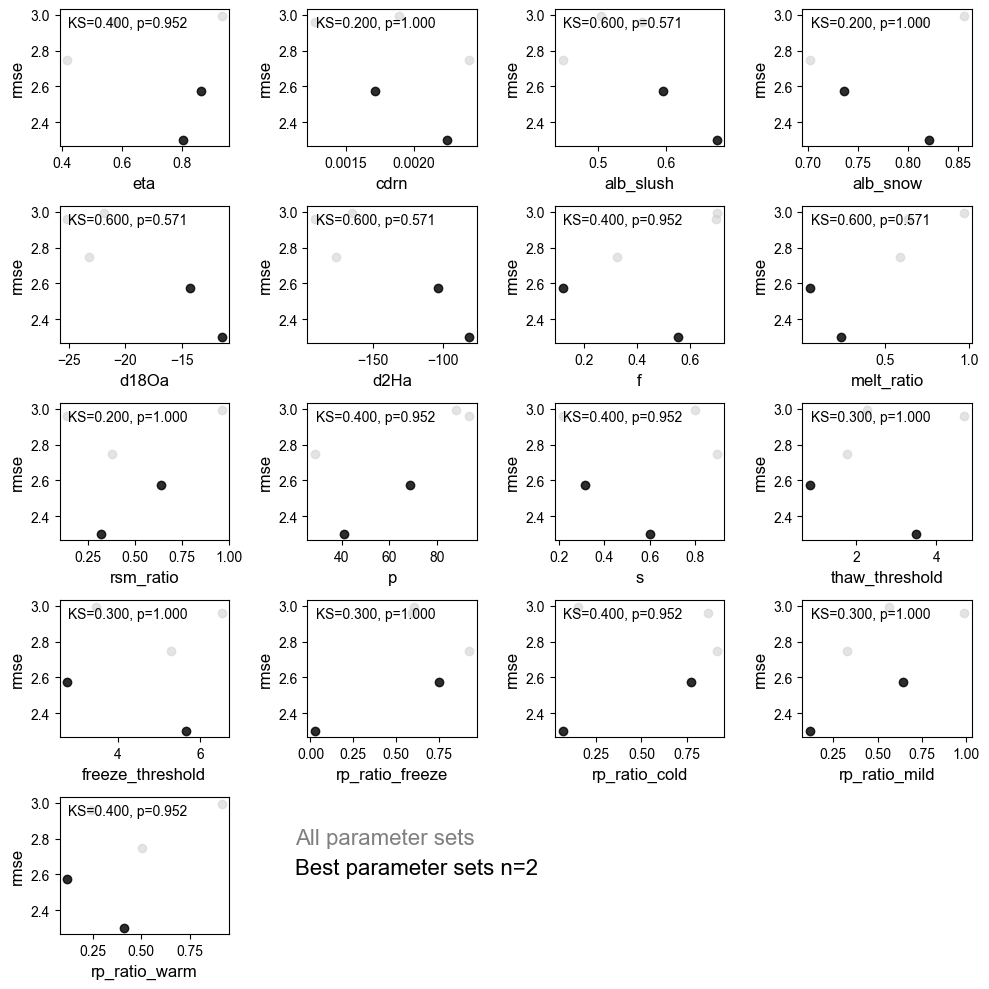

In [11]:
# Visualize the calibration in parameter space
scatter_temp = scatterplot_stats_vs_params(stats, params, stat_col='rmse', params_list = None, trials_list=good_trials) # Example files only have 5 simulations

scatter_temp.savefig('/Users/rebec/OneDrive/Documents/calibration/figures/BearLake-temperature-scatterplot.png')

In [13]:
s = temp_sims.sel(trial = good_trials) # For these calibrated trials, how does the surface and bottom do? 

# Prepare obs and model 
pred, true = prep_pred_obs(
    s, temp_obs,
    sims_col="temp",
    obs_col="temperature",
    depth_filter = lambda d: (d >= 7), # within the last meter = bottom 
)

bottom_scores = calc_rmse(pred, true)

# Prepare obs and model 
pred, true = prep_pred_obs(
    s, temp_obs,
    sims_col="temp",
    obs_col="temperature",
    depth_filter = lambda d: (d <= 1), # within the first meter = surface 
)

surface_scores = calc_rmse(pred, true)

In [14]:
# Print data to include in a table 

surface_summary = surface_scores.sort_values('rmse').head(30).mean()
bottom_summary = bottom_scores.sort_values('rmse').head(30).mean()
all_summary = scores.sort_values('rmse').head(30).mean()

print(f"Surface RMSE mean of best 30: {surface_summary['rmse']:.2f} °C")
print(f"Bottom RMSE mean of best 30: {bottom_summary['rmse']:.2f} °C")
print(f"All depths RMSE mean of best 30: {all_summary['rmse']:.2f} °C")
print("-----------------------------------------")
print(f"Surface bias mean of best 30: {surface_summary['bias']:.2f} °C")
print(f"Bottom bias mean of best 30: {bottom_summary['bias']:.2f} °C")
print(f"All depths bias mean of best 30: {all_summary['bias']:.2f} °C")

Surface RMSE mean of best 30: 0.94 °C
Bottom RMSE mean of best 30: 7.16 °C
All depths RMSE mean of best 30: 2.72 °C
-----------------------------------------
Surface bias mean of best 30: -0.33 °C
Bottom bias mean of best 30: -7.12 °C
All depths bias mean of best 30: -0.16 °C


## Plot timeseries for water temp

In [ ]:
# Set-up the modeled depths you want to plot

T1m = get_any_depth(temp_sims["temp"], depth = 0.81) # Depths of data loggers that monitored continuous for a period

T4m = get_any_depth(temp_sims["temp"], depth = 3.51)

Tbottom = get_any_depth(temp_sims["temp"], depth = 6.47) 

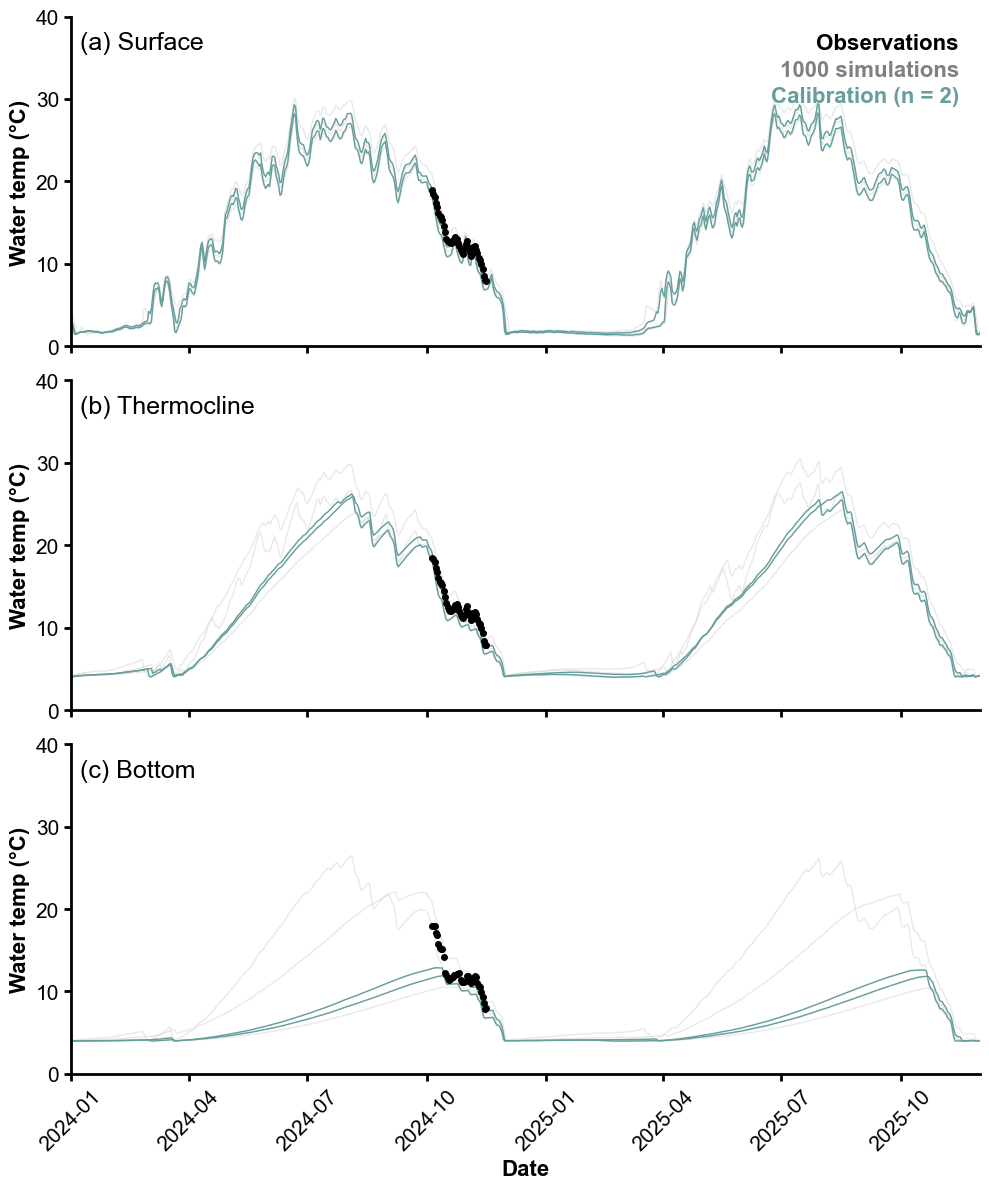

In [ ]:
# Plot up sims and observations as timesries # 

# Set up the figure 
fig, axes = plt.subplots(nrows = 3, ncols = 1, figsize = (10,12), sharex = True)

# Set up simulationes
tepi_sims = T1m.to_pandas()
tthermo_sims = T4m.to_pandas()
tbottom_sims = Tbottom.to_pandas()

# Pull the observations 
tepi_obs = temp_obs[temp_obs['Depth'] == 0.81]
tthermo_obs = temp_obs[temp_obs['Depth'] == 3.51]
tbottom_obs = temp_obs[temp_obs['Depth'] == 6.47]

# Make trials strings to match sims
good_temp_trials = np.array(good_trials).astype(np.int32)

# Plot all simulations (gray lines)
for col in tepi_sims.columns:
    axes[0].plot(tepi_sims.index, tepi_sims[col], linewidth=1, color="lightgray", alpha=0.5)

# Plot top trials (light blue lines)
for trial in good_temp_trials:
    if trial in tepi_sims.columns:
        axes[0].plot(tepi_sims.index, tepi_sims[trial], linewidth=1, color='#659F9D')

# Plot all simulations (gray lines)
for col in tthermo_sims.columns:
    axes[1].plot(tthermo_sims.index, tthermo_sims[col], linewidth=1, color="lightgray", alpha=0.5)

# Plot top trials (light blue lines)
for trial in good_temp_trials:
    if trial in tthermo_sims.columns:
        axes[1].plot(tthermo_sims.index, tthermo_sims[trial], linewidth=1, color='#659F9D')

# Plot all simulations (gray lines)
for col in tbottom_sims.columns:
    axes[2].plot(tbottom_sims.index, tbottom_sims[col], linewidth=1, color="lightgray", alpha=0.5)

# Plot top trials (light blue lines)
for trial in good_temp_trials:
    if trial in tbottom_sims.columns:
        axes[2].plot(tbottom_sims.index, tbottom_sims[trial], linewidth=1, color='#659F9D')

# Plot observations as dots
axes[0].scatter(tepi_obs.index, tepi_obs['temperature'], s=16, zorder = 5, color = 'k')
axes[1].scatter(tthermo_obs.index, tthermo_obs['temperature'], s=16, zorder = 5, color = 'k')
axes[2].scatter(tbottom_obs.index, tbottom_obs['temperature'], s=16, zorder = 5, color = 'k')


# Only on the top plot, add legend 
axes[0].text(0.977, 0.90, "Observations", transform=axes[0].transAxes, color = 'k', fontsize = 16, ha = 'right', fontweight = 'bold')
axes[0].text(0.977, 0.82, "1000 simulations", transform=axes[0].transAxes, color = 'gray', fontsize = 16, ha = 'right', fontweight = 'bold')
axes[0].text(0.977, 0.74, f"Calibration (n = {len(good_temp_trials)})", transform=axes[0].transAxes, color = '#659F9D', fontsize = 16, ha = 'right', fontweight = 'bold')

# Format the axes
for ax in axes:
    # X axis labels
    ax.xaxis.set_major_formatter(DateFormatter("%Y-%m"))
    ax.tick_params(axis='both', which='major', labelsize = 15, length = 5, width = 2)
    # Remove and edit spines (plot borders)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(2)
    ax.spines['bottom'].set_linewidth(2)
    # Y axis label
    ax.set_ylabel("Water temp (°C)", fontsize = 16, fontweight = 'bold')
    ax.set_ylim(0,40)

# X-axis limits
ax.set_xlim(pd.Timestamp("2024-01-01"), pd.Timestamp("2025-12-01")) # Plot 2024 through 2025

# Rotate the x tick labels
for label in ax.get_xticklabels():
    label.set_rotation(45)

# X axis label only on the last plot
axes[2].set_xlabel("Date", fontsize = 16, fontweight = 'bold')

# Plot subtitles 
axes[0].text(0.01, 0.90, "(a) Surface", transform=axes[0].transAxes, fontsize = 18)
axes[1].text(0.01, 0.90, "(b) Thermocline", transform=axes[1].transAxes, fontsize = 18)
axes[2].text(0.01, 0.90, "(c) Bottom", transform=axes[2].transAxes, fontsize = 18)

plt.tight_layout()

#plt.savefig('/Users/rebec/OneDrive/Documents/calibration/figures/BearLake-temp-calibration-timeseries.png', dpi = 300)

plt.show()

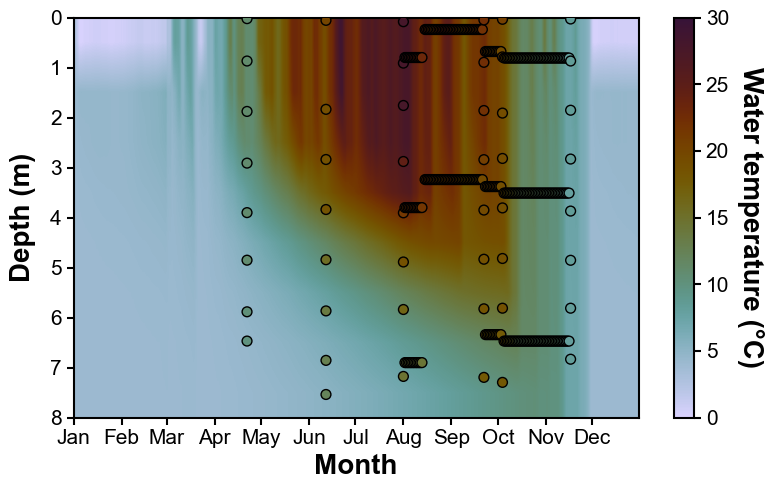

In [ ]:
### MAKE A HEATMAP ###

# MODEL SET-UP #
model_depth_idx = pd.to_numeric(temp_sims['temp']['variable'].values) # Model depth is called 'variable', make sure it's numeric
# Adjust the model layers to depths in meters (the model run at 1m resolution gives 1m layer averages, we treat these as midpoints i.e. layer 1 is 0.5 meters and so on)
tprof_sims = temp_sims['temp'].assign_coords({'variable': model_depth_idx - 0.5}).sortby('variable')

# Change format of trial #s in calibration list 
good_temp_trials = np.array(good_trials).astype(np.int32)

# Select only the good trials from all trials 
tprof_sims_good = tprof_sims.sel(trial=good_temp_trials)

# Take the mean over all good trials
tprof_sims_good_mean = tprof_sims_good.mean(dim='trial') # Mean over dimension = trial
temp_averages = tprof_sims_good_mean.to_pandas() # Convert to pandas df


# PLOT SETTINGS # 
cmap = cm.glasgow_r # Use crameri colormaps, which are colorblind friendly!

# Choose the year we want to plot 
tsims_2024 = temp_averages[temp_averages.index.year == 2024] 

# Grab obs only from the same year and sort by index 
temp_obs_2024 = temp_obs[temp_obs.index.year == 2024].sort_index()

min = 0 # 0 deg C minimum value 
max = 30 # 30 deg C maximum value

# MAKE A HEATMAP #
# Figure set up
fig, ax = plt.subplots(figsize=(8, 5))

# Plot the heat map
im = ax.imshow(
    tsims_2024.values.T,
    aspect="auto",
    origin="upper",
    interpolation = "bilinear", # Change for smoother heatmap (model resolution is 1m), or can choose 'none'
    extent=[
        mdates.date2num(tsims_2024.index[0]), # X axis limits
        mdates.date2num(tsims_2024.index[-1]),
        tsims_2024.columns[-1] + 0.5, tsims_2024.columns[0] - 0.5,  ], # Y axis limits
        cmap = cmap, 
        vmin = min,
        vmax = max,
)

# Plot the observations on top
sc = ax.scatter(
    temp_obs_2024.index,
    temp_obs_2024["Depth"],
    c=temp_obs_2024["temperature"],
    cmap = cmap,     
    edgecolor = "k",
    s = 50,
    vmin = min,
    vmax = max,
    zorder = 5,
)

# Format labels and axes labels 
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
ax.set_ylabel("Depth (m)", fontsize = 20, fontweight = 'bold', labelpad = 10)
ax.set_xlabel("Month", fontsize = 20, fontweight = 'bold')
# Change y-tick label size 
ax.tick_params(axis='both', which='major', labelsize = 15, length = 5, width = 1.5)

# Plot border width 
ax.spines['top'].set_linewidth(1.5)
ax.spines['right'].set_linewidth(1.5)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)

# Format the colorbar
cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Water temperature (°C)", fontsize = 20, rotation = 270, labelpad = 25, fontweight = 'bold')
cbar.ax.tick_params(labelsize=15, width = 1.5, length = 5)
for spine in cbar.ax.spines.values():
    spine.set_linewidth(1.5) 

plt.tight_layout()

# Save the plot 
#plt.savefig('/Users/rebec/OneDrive/Documents/calibration/figures/BearLake-temp-calibration-heatmap.png', dpi = 300)

plt.show()

# (2) Water isotope calibration

In [73]:
iso_obs = pd.read_csv('/Users/rebec/OneDrive/Documents/calibration/obs/BearLake-waterisotope-observations.csv', index_col = 'Date', parse_dates=True)

In [72]:
# Read in model outputs 
path = '/Users/rebec/OneDrive/Documents/calibration/output/'

d2H_sims = xr.open_dataset(path + 'lake-model-d2H.nc') # For profiles, 'variable' dimension = lake layer depth
d2H_sims

<xarray.Dataset> Size: 4MB
Dimensions:   (time: 11322, variable: 8, trial: 5)
Coordinates:
  * time      (time) datetime64[ns] 91kB 1995-01-01 1995-01-02 ... 2025-12-30
  * variable  (variable) object 64B '1' '2' '3' '4' '5' '6' '7' '8'
  * trial     (trial) int32 20B 0 1 2 3 4
Data variables:
    d2H       (time, variable, trial) float64 4MB ...

In [77]:
# Prepare obs and model 
pred, true = prep_pred_obs(
    d2H_sims, iso_obs,
    sims_col="d2H",
    obs_col="d2H_water",
)

# Calculate RMSE between observations and modeled values 
scores = calc_rmse(pred, true)

In [78]:
# Print out the dataframe, and sort the order by RMSE value (best -> worst)
scores.sort_values('rmse')

,trial,rmse,bias,nse,n_points
0,0,12.718043,-2.483324,-1.296488,49
3,3,12.865445,7.291686,-1.350028,49
4,4,13.317792,-2.921380,-1.518187,49
2,2,13.372252,-1.335916,-1.538824,49
1,1,16.384420,6.382041,-2.811410,49


In [ ]:
# Merge stats and parameter values 

# Make sure both trial columns are numeric 
scores["trial"] = pd.to_numeric(scores["trial"])
params["trial"] = pd.to_numeric(params["trial"])

# Add parameter values 
stats = pd.merge(scores, params, left_on='trial', right_on='trial', how='outer')

# Save the calibration dataframe
#stats.to_csv('/Users/rebec/OneDrive/Documents/calibration/BearLake-d2H-calibration.csv')

## Scatterplot figure

Number of best trials: 2
Parameter: eta, Min: 0.805252, Max: 0.863360
Parameter: cdrn, Min: 0.001714, Max: 0.002243
Parameter: alb_slush, Min: 0.594898, Max: 0.673203
Parameter: alb_snow, Min: 0.735717, Max: 0.820205
Parameter: d18Oa, Min: -14.259080, Max: -11.472211
Parameter: d2Ha, Min: -104.072636, Max: -81.777689
Parameter: f, Min: 0.118061, Max: 0.555095
Parameter: melt_ratio, Min: 0.053108, Max: 0.239773
Parameter: rsm_ratio, Min: 0.319031, Max: 0.636829
Parameter: p, Min: 41.088293, Max: 68.557609
Parameter: s, Min: 0.314287, Max: 0.599035
Parameter: thaw_threshold, Min: 0.857937, Max: 3.494959
Parameter: freeze_threshold, Min: 2.781995, Max: 5.649220
Parameter: rp_ratio_freeze, Min: 0.026124, Max: 0.748751
Parameter: rp_ratio_cold, Min: 0.066032, Max: 0.772789
Parameter: rp_ratio_mild, Min: 0.120466, Max: 0.644883
Parameter: rp_ratio_warm, Min: 0.119304, Max: 0.409718
Average RMSE of top 2 runs: 2.437951358397025
2.3005954827558504 - 2.5753072340381995 RMSE range for top 2 runs

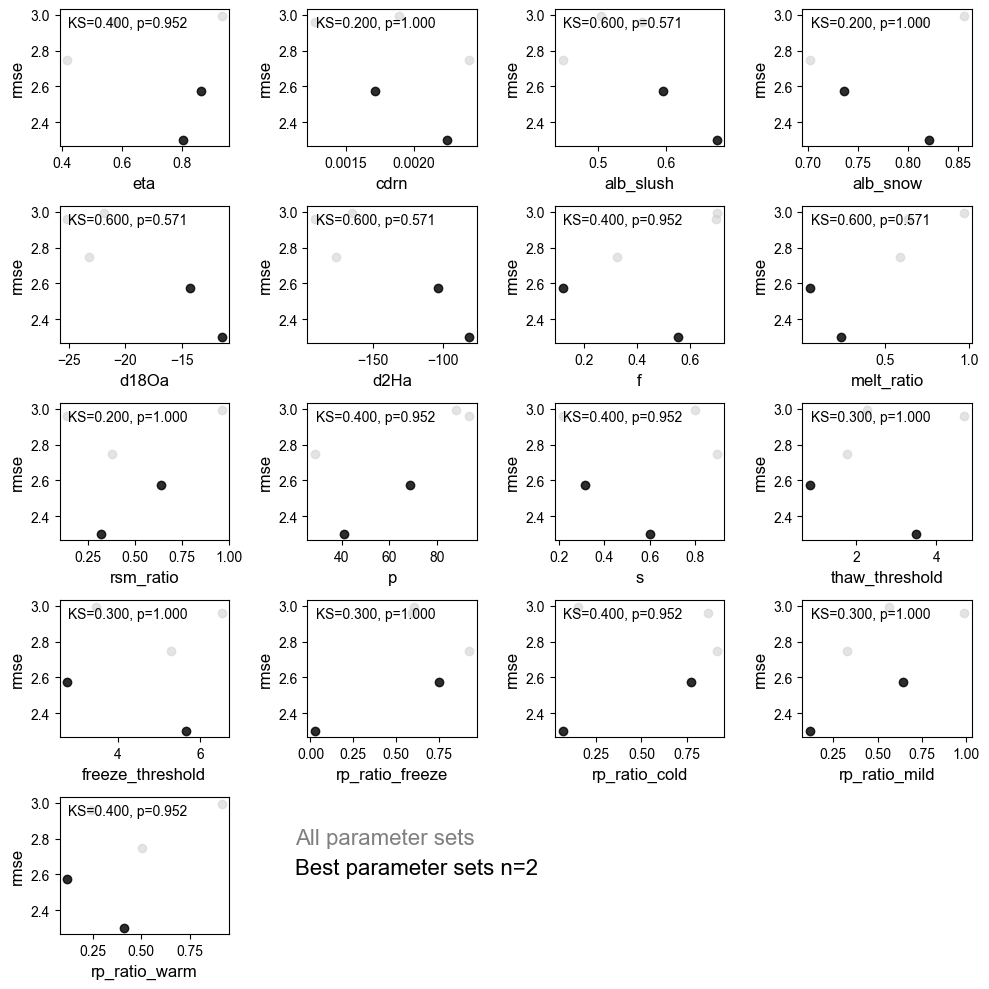

In [12]:
# Visualize the calibration in parameter space
scatter_d2H = scatterplot_stats_vs_params(stats, params, stat_col='rmse', params_list = None, trials_list=good_trials) # Example files only have 5 simulations

scatter_d2H.savefig('/Users/rebec/OneDrive/Documents/calibration/figures/BearLake-d2H-scatterplot.png')

In [81]:
s = d2H_sims.sel(trial = good_trials) # For these calibrated trials, how does the surface and bottom do? 

# Prepare obs and model 
pred, true = prep_pred_obs(
    s, iso_obs,
    sims_col="d2H",
    obs_col="d2H_water",
    depth_filter = lambda d: (d >= 7), # within the last meter = bottom 
)

bottom_scores = calc_rmse(pred, true)

# Prepare obs and model 
pred, true = prep_pred_obs(
    s, iso_obs,
    sims_col="d2H",
    obs_col="d2H_water",
    depth_filter = lambda d: (d <= 1), # within the first meter = surface 
)

surface_scores = calc_rmse(pred, true)

In [84]:
# Print data to include in a table 

surface_summary = surface_scores.sort_values('rmse').head(30).mean()
bottom_summary = bottom_scores.sort_values('rmse').head(30).mean()
all_summary = scores.sort_values('rmse').head(30).mean()

print(f"Surface RMSE mean of best 30: {surface_summary['rmse']:.2f} ‰")
print(f"Surface bias mean of best 30: {surface_summary['bias']:.2f} ‰")
print("-----------------------------------------")

print(f"Bottom RMSE mean of best 30: {bottom_summary['rmse']:.2f} ‰")
print(f"Bottom bias mean of best 30: {bottom_summary['bias']:.2f} ‰")
print("-----------------------------------------")

print(f"All depths RMSE mean of best 30: {all_summary['rmse']:.2f} ‰")
print(f"All depths bias mean of best 30: {all_summary['bias']:.2f} ‰")

Surface RMSE mean of best 30: 18.14 ‰
Surface bias mean of best 30: 10.75 ‰
-----------------------------------------
Bottom RMSE mean of best 30: 9.60 ‰
Bottom bias mean of best 30: -5.28 ‰
-----------------------------------------
All depths RMSE mean of best 30: 13.73 ‰
All depths bias mean of best 30: 1.39 ‰


## Timeseries figure

In [85]:
# Set-up the modeled depths you want to plot

d2H1m = get_any_depth(d2H_sims['d2H'], depth = 1.0)

d2H4m = get_any_depth(d2H_sims['d2H'], depth = 4.0)

d2Hbottom = get_any_depth(d2H_sims['d2H'], depth = 7.0)

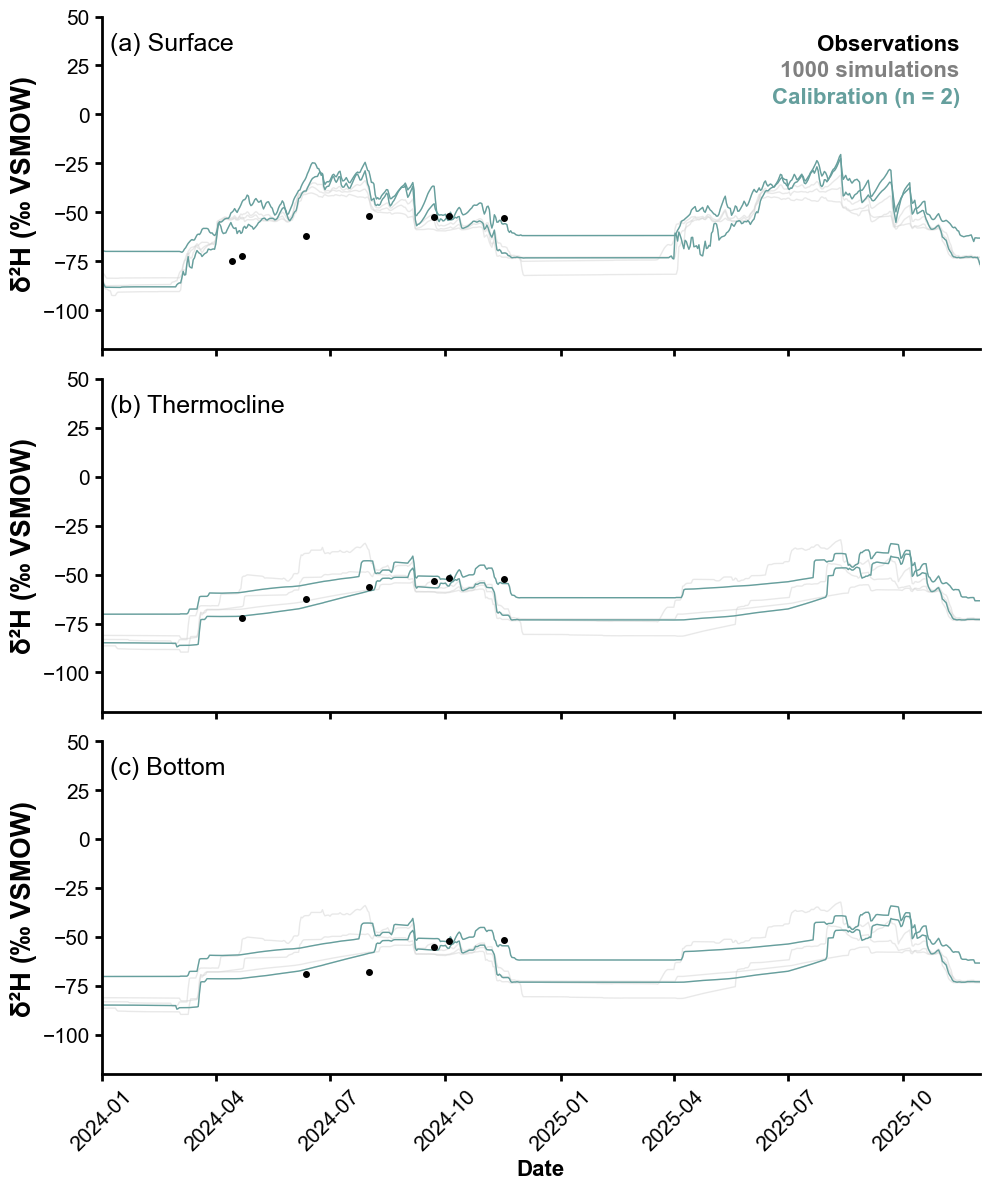

In [ ]:
# Plot up sims and observations as timesries # 

# Set up the figure 
fig, axes = plt.subplots(nrows = 3, ncols = 1, figsize = (10,12), sharex = True)

# Set up simulationes
epi_sims = d2H1m.to_pandas()
thermo_sims = d2H4m.to_pandas()
bottom_sims = d2Hbottom.to_pandas()

# Pull the observations 
epi_obs = iso_obs[iso_obs['Depth'] == 1.0]
thermo_obs = iso_obs[iso_obs['Depth'] == 4.0]
bottom_obs = iso_obs[iso_obs['Depth'] == 7.0]

# Make trials strings to match sims
good_temp_trials = np.array(good_trials).astype(np.int32)

# Plot all simulations (gray lines)
for col in epi_sims.columns:
    axes[0].plot(epi_sims.index, epi_sims[col], linewidth=1, color="lightgray", alpha=0.5)

# Plot top trials (light blue lines)
for trial in good_temp_trials:
    if trial in epi_sims.columns:
        axes[0].plot(epi_sims.index, epi_sims[trial], linewidth=1, color='#659F9D')

# Plot all simulations (gray lines)
for col in thermo_sims.columns:
    axes[1].plot(thermo_sims.index, thermo_sims[col], linewidth=1, color="lightgray", alpha=0.5)

# Plot top trials (light blue lines)
for trial in good_temp_trials:
    if trial in thermo_sims.columns:
        axes[1].plot(thermo_sims.index, thermo_sims[trial], linewidth=1, color='#659F9D')

# Plot all simulations (gray lines)
for col in thermo_sims.columns:
    axes[2].plot(thermo_sims.index, thermo_sims[col], linewidth=1, color="lightgray", alpha=0.5)

# Plot top trials (light blue lines)
for trial in good_temp_trials:
    if trial in thermo_sims.columns:
        axes[2].plot(thermo_sims.index, thermo_sims[trial], linewidth=1, color='#659F9D')

# Plot observations as dots
axes[0].scatter(epi_obs.index, epi_obs['d2H_water'], s=16, zorder = 5, color = 'k')
axes[1].scatter(thermo_obs.index, thermo_obs['d2H_water'], s=16, zorder = 5, color = 'k')
axes[2].scatter(bottom_obs.index, bottom_obs['d2H_water'], s=16, zorder = 5, color = 'k')


# Only on the top plot, add legend 
axes[0].text(0.977, 0.90, "Observations", transform=axes[0].transAxes, color = 'k', fontsize = 16, ha = 'right', fontweight = 'bold')
axes[0].text(0.977, 0.82, "1000 simulations", transform=axes[0].transAxes, color = 'gray', fontsize = 16, ha = 'right', fontweight = 'bold')
axes[0].text(0.977, 0.74, f"Calibration (n = {len(good_temp_trials)})", transform=axes[0].transAxes, color = '#659F9D', fontsize = 16, ha = 'right', fontweight = 'bold')

# Format the axes
for ax in axes:
    # X axis labels
    ax.xaxis.set_major_formatter(DateFormatter("%Y-%m"))
    ax.tick_params(axis='both', which='major', labelsize = 15, length = 5, width = 2)
    # Remove and edit spines (plot borders)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(2)
    ax.spines['bottom'].set_linewidth(2)
    # Y axis label
    ax.set_ylabel('\u03B4\u00B2H (‰ VSMOW)', fontsize = 20, fontweight = 'bold')
    ax.set_ylim(-120, 50)

# X-axis limits
ax.set_xlim(pd.Timestamp("2024-01-01"), pd.Timestamp("2025-12-01")) # Plot 2024 through 2025

# Rotate the x tick labels
for label in ax.get_xticklabels():
    label.set_rotation(45)

# X axis label only on the last plot
axes[2].set_xlabel("Date", fontsize = 16, fontweight = 'bold')

# Plot subtitles 
axes[0].text(0.01, 0.90, "(a) Surface", transform=axes[0].transAxes, fontsize = 18)
axes[1].text(0.01, 0.90, "(b) Thermocline", transform=axes[1].transAxes, fontsize = 18)
axes[2].text(0.01, 0.90, "(c) Bottom", transform=axes[2].transAxes, fontsize = 18)

plt.tight_layout()

#plt.savefig('/Users/rebec/OneDrive/Documents/calibration/figures/BearLake-d2H-calibration-timeseries.png', dpi = 300)

plt.show()

## (3) Examine runoff inputs

In [89]:
# Read in model outputs 
path = '/Users/rebec/OneDrive/Documents/calibration/output/'

met_sims = xr.open_dataset(path + 'lake-model-met.nc') # For profiles, 'variable' dimension = lake layer depth
met_sims

<xarray.Dataset> Size: 7MB
Dimensions:   (time: 11688, variable: 15, trial: 5)
Coordinates:
  * time      (time) datetime64[ns] 94kB 1994-01-01 1994-01-02 ... 2025-12-31
  * variable  (variable) object 120B 'T2M' 'D2M' 'WIND' ... 'd18OACC' 'd2HACC'
    units     (variable) object 120B ...
  * trial     (trial) int32 20B 0 1 2 3 4
Data variables:
    met       (time, variable, trial) float64 7MB ...

## Timeseries plot

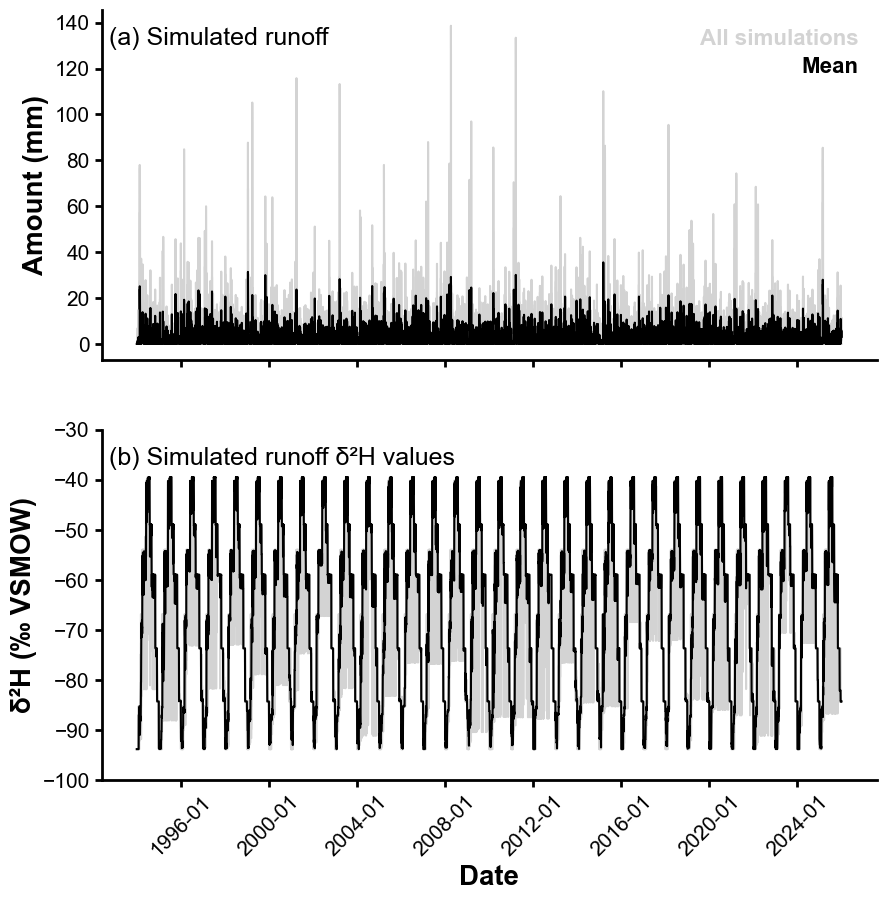

In [ ]:
fig, axes = plt.subplots(nrows = 2, ncols = 1, figsize = (10,10), sharex = True)

# Set up sims
runoff_amount = met_sims['met'].sel(variable = 'RUNOFF').to_pandas()
runoff_d2H = met_sims['met'].sel(variable = 'd2HR').to_pandas()

for col in runoff_amount.columns: 
    axes[0].plot(runoff_amount.index, runoff_amount[col], color = 'lightgray')
axes[0].plot(runoff_amount.index, runoff_amount.mean(axis = 1), color = 'k')

for col in runoff_d2H.columns: 
    axes[1].plot(runoff_d2H.index, runoff_d2H[col], color = 'lightgray')
axes[1].plot(runoff_d2H.index, runoff_d2H.mean(axis = 1), color = 'k')


axes[1].set_ylim(-100, -30)

for ax in axes:
    # X axis labels
    ax.xaxis.set_major_formatter(DateFormatter("%Y-%m"))
    ax.tick_params(axis='both', which='major', labelsize = 15, length = 5, width = 2)
    # Remove and edit spines (plot borders)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(2)
    ax.spines['bottom'].set_linewidth(2)

for label in ax.get_xticklabels():
    label.set_rotation(45)

axes[1].set_xlabel('Date', fontsize = 20, fontweight = 'bold')
axes[1].set_ylabel('\u03B4\u00B2H (‰ VSMOW)', fontsize = 20, fontweight = 'bold')

axes[0].set_ylabel('Amount (mm)', fontsize = 20, fontweight = 'bold')

axes[0].text(0.01, 0.90, "(a) Simulated runoff", transform=axes[0].transAxes, fontsize = 18)
axes[1].text(0.01, 0.90, "(b) Simulated runoff \u03B4\u00B2H values ", transform=axes[1].transAxes, fontsize = 18)

axes[0].text(0.977, 0.90, "All simulations", transform=axes[0].transAxes, color = 'lightgray', fontsize = 16, ha = 'right', fontweight = 'bold')
axes[0].text(0.977, 0.82, "Mean", transform=axes[0].transAxes, color = 'k', fontsize = 16, ha = 'right', fontweight = 'bold')

#plt.savefig('/Users/rebec/OneDrive/Documents/calibration/figures/runoff-timeseries.png', dpi = 300 )

plt.show()